# P-Value and Significance Level (α)

This notebook demonstrates:

- Null and Alternate Hypothesis
- Z-statistic
- P-value
- Significance Level (α)
- Confidence Level
- Critical Value
- Rejection Region
- Decision using P-value and α

### Example

A coin is tossed 100 times and produces 70 heads.

We want to test whether the coin is fair.

$$
H_0: p = 0.5
$$

$$
H_1: p \neq 0.5
$$

This is a **two-tailed hypothesis test**.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Define the Problem

We have:

- Number of tosses = 100
- Number of heads = 70
- Expected probability of heads = 0.5
- Significance Level = 0.05

The sample proportion is:

$$
\hat{p} = \frac{x}{n}
$$

In [2]:
n = 100
heads = 70
p0 = 0.5
alpha = 0.05

p_hat = heads / n

print("Number of tosses:", n)
print("Number of heads:", heads)
print("Expected probability:", p0)
print("Sample proportion:", p_hat)
print("Significance level (α):", alpha)

Number of tosses: 100
Number of heads: 70
Expected probability: 0.5
Sample proportion: 0.7
Significance level (α): 0.05


## 2. Define the Hypotheses

### Null Hypothesis

$$
H_0: p = 0.5
$$

The coin is fair.

### Alternate Hypothesis

$$
H_1: p \neq 0.5
$$

The coin is not fair.

Since the alternate hypothesis uses `≠`, this is a **two-tailed test**.

## 3. Calculate the Z-Statistic

For a one-sample proportion test:

$$
Z =
\frac{\hat{p} - p_0}
{\sqrt{\frac{p_0(1-p_0)}{n}}}
$$

where:

- $\hat{p}$ = Sample proportion
- $p_0$ = Population proportion under $H_0$
- $n$ = Sample size

In [3]:
standard_error = math.sqrt(p0 * (1 - p0) / n)

z_stat = (p_hat - p0) / standard_error

print("Standard Error:", standard_error)
print("Z-statistic:", z_stat)

Standard Error: 0.05
Z-statistic: 3.999999999999999


## 4. Calculate the P-Value

For a two-tailed test:

$$
P\text{-value} = 2P(Z \geq |z|)
$$

We can calculate it using SciPy.

In [4]:
p_value = 2 * stats.norm.sf(abs(z_stat))

print("P-value:", p_value)

P-value: 6.334248366623996e-05


## 5. Compare P-Value with α

Decision rule:

$$
p < \alpha
\Rightarrow
\text{Reject } H_0
$$

$$
p \geq \alpha
\Rightarrow
\text{Fail to Reject } H_0
$$

In [5]:
if p_value < alpha:
    decision = "Reject H₀"
    interpretation = (
        "There is sufficient evidence to conclude that "
        "the coin is not fair."
    )
else:
    decision = "Fail to Reject H₀"
    interpretation = (
        "There is insufficient evidence to conclude that "
        "the coin is not fair."
    )

print("Decision:", decision)
print("Interpretation:", interpretation)

Decision: Reject H₀
Interpretation: There is sufficient evidence to conclude that the coin is not fair.


## 6. Confidence Level

The relationship between significance level and confidence level is:

$$
\text{Confidence Level} = 1 - \alpha
$$

For:

$$
\alpha = 0.05
$$

we get:

$$
1 - 0.05 = 0.95
$$

Therefore, the confidence level is **95%**.

In [6]:
confidence_level = 1 - alpha

print("Significance Level:", alpha)
print("Confidence Level:", confidence_level)
print("Confidence Level (%):", confidence_level * 100)

Significance Level: 0.05
Confidence Level: 0.95
Confidence Level (%): 95.0


## 7. Critical Value

For a two-tailed test with:

$$
\alpha = 0.05
$$

the critical values are approximately:

$$
z = \pm 1.96
$$

If:

$$
|Z| > 1.96
$$

we reject $H_0$.

In [7]:
critical_value = stats.norm.ppf(1 - alpha / 2)

print("Critical Value:", critical_value)
print("Lower Critical Value:", -critical_value)
print("Upper Critical Value:", critical_value)

if abs(z_stat) > critical_value:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to Reject H₀")

Critical Value: 1.959963984540054
Lower Critical Value: -1.959963984540054
Upper Critical Value: 1.959963984540054
Decision: Reject H₀


## 8. Visualizing the Rejection Regions

For a two-tailed test with α = 0.05:

- Left rejection region = 2.5%
- Middle region = 95%
- Right rejection region = 2.5%

Critical values:

$$
-1.96 \quad \text{and} \quad 1.96
$$

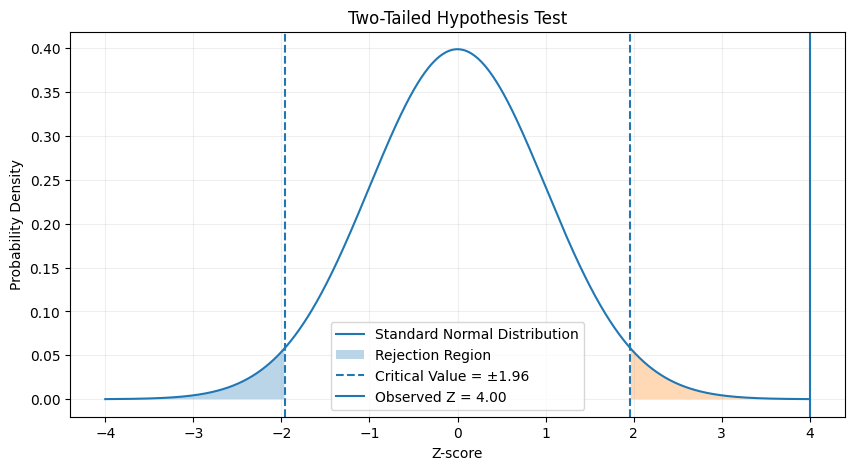

In [8]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 5))

plt.plot(x, y, label="Standard Normal Distribution")

left_region = x <= -critical_value
right_region = x >= critical_value

plt.fill_between(
    x[left_region],
    y[left_region],
    alpha=0.3,
    label="Rejection Region"
)

plt.fill_between(
    x[right_region],
    y[right_region],
    alpha=0.3
)

plt.axvline(
    -critical_value,
    linestyle="--",
    label=f"Critical Value = ±{critical_value:.2f}"
)

plt.axvline(
    critical_value,
    linestyle="--"
)

plt.axvline(
    z_stat,
    linestyle="-",
    label=f"Observed Z = {z_stat:.2f}"
)

plt.title("Two-Tailed Hypothesis Test")
plt.xlabel("Z-score")
plt.ylabel("Probability Density")

plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 9. Try Different P-Values

The decision depends on the relationship between the P-value and α.

### Example 1

$$
p = 0.03
$$

$$
\alpha = 0.05
$$

Since:

$$
0.03 < 0.05
$$

we reject $H_0$.

In [9]:
p_value_example = 0.03

if p_value_example < alpha:
    print("P-value:", p_value_example)
    print("Decision: Reject H₀")
else:
    print("P-value:", p_value_example)
    print("Decision: Fail to Reject H₀")

P-value: 0.03
Decision: Reject H₀


### Example 2

$$
p = 0.08
$$

$$
\alpha = 0.05
$$

Since:

$$
0.08 \geq 0.05
$$

we fail to reject $H_0$.

In [10]:
p_value_example = 0.08

if p_value_example < alpha:
    print("P-value:", p_value_example)
    print("Decision: Reject H₀")
else:
    print("P-value:", p_value_example)
    print("Decision: Fail to Reject H₀")

P-value: 0.08
Decision: Fail to Reject H₀


# Key Takeaways

- **P-value** measures how surprising the observed result is under $H_0$.
- **α** is the predefined significance threshold.
- A common significance level is **0.05**.
- Confidence Level:

$$
1 - \alpha
$$

- If:

$$
p < \alpha
$$

  → **Reject $H_0$**

- If:

$$
p \geq \alpha
$$

  → **Fail to Reject $H_0$**

- A P-value is **not** the probability that $H_0$ is true.
- Statistical significance does not necessarily imply practical significance.